In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


In [3]:
df = pd.read_csv('22_열처리.csv', encoding='utf-8')
print(df.shape)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()
norm = df[['제어출력', '소입로온도']].asfreq('10s')

(188, 4)


## 실습 1. ffill과 bfill 비교
빈 칸을 앞값·뒷값으로 채우고 조합해 남는 결측 확인

목표
- 빈 칸을 앞값·뒷값으로 채우고 조합해 남는 결측을 확인

단계
- 정규화 데이터의 제어출력을 앞값으로 채우기
- 같은 데이터를 뒷값으로 채우기
- 두 방법을 이어 붙여 맨 앞뒤 빈 칸까지 채우기

예상 결과
- 앞값·뒷값 각각 빈 칸 0, 조합도 0

In [4]:
# [전방 채우기(ffill)와 후방 채우기(bfill)의 기본 동작 검증]
# 1. ffill(): 결측치가 발생하면 이전 시점(과거)의 가장 최근 값을 미래로 복사하여 NaN을 메꿉니다.
# 2. bfill(): 결측치가 발생하면 다음 시점(미래)의 첫 정상 값을 과거로 당겨와서 복사합니다.
# * 제어출력과 같은 조작 변수들은 설정 값을 유지하는 특성이 많아 ffill을 사용하는 것이
#   물리적 흐름에 부합하며, 상황에 따라 앞뒤를 모두 섞어(`ffill().bfill()`) 완전 정제를 기하기도 합니다.
# * 데이터가 시간 순으로 완벽히 정렬된 상태에서 ffill을 해야 과거 값이 미래로 제대로 전달됩니다.
#   정렬되지 않은 데이터에 ffill을 쓰는 것은 무작위 수치를 복사해 넣는 실책이 됩니다.

print('ffill:', int(norm['제어출력'].ffill().isna().sum()))
print('bfill:', int(norm['제어출력'].bfill().isna().sum()))
print('ffill+bfill:', int(norm['제어출력'].ffill().bfill().isna().sum()))

ffill: 0
bfill: 0
ffill+bfill: 0


## 실습 2. 보간 방법 비교 (선형·시간)
선형 보간과 시간 보간의 차이를 예시와 실데이터로 비교

목표
- 선형 보간과 시간 보간의 차이를 작은 예시와 실데이터로 비교

단계
- 세 시점 예시에서 선형과 시간 보간의 가운데 값을 비교
- 정규화 데이터에 두 보간을 적용
- 두 결과가 다른 칸 수를 확인

예상 결과
- 예시에서 선형은 25, 시간은 15; 실데이터는 등간격이라 선형과 시간이 같음(0개)

In [5]:
# [정밀 격자 환경에서의 선형(linear) 보간과 시간(time) 보간의 일치 여부 대조]
# 1. `lin != tim`: 선형 보간 결과와 시간 기반 보간 결과가 달라지는 포인트를 불리언 시리즈로 찾아 합을 구합니다.
# * asfreq('10s')를 통해 시간 인덱스가 완벽히 동일한 10초 간격으로 강제 배정(정규 격자)되었으므로,
#   행 간격 물리 계산(linear)과 실제 시간 비례 경사 계산(time)의 수치가 수학적으로 완전히 일치하게 됨을 검증합니다.
# * 실수형(float) 데이터를 비교할 때 소수점 미세 라운딩 에러로 인해 미세하게 다를 수 있으나,
#   판다스의 기본적인 연산 내에서는 동일한 격자에서 두 함수 결과는 완벽한 일치를 보입니다.
# =============================================================================
lin = norm['제어출력'].interpolate()
tim = norm['제어출력'].interpolate(method='time')
print('선형과 시간이 다른 칸 수:', int((lin != tim).sum()))     # 0 (균일 격자라 동일)

선형과 시간이 다른 칸 수: 0


## 실습 3. 긴 누락 구간과 limit
연속 결측 길이를 보고 채우기 범위를 제한해 긴 구간 남기기

목표
- 연속 결측 길이를 확인하고 채우기 범위를 제한해 긴 구간을 남기기

단계
- 빈 값이 연속으로 이어진 길이들을 구하기
- 제한 없이 보간하면 모두 채워짐을 확인
- 연속 두 칸까지만 채우면 긴 구간은 남음을 확인

예상 결과
- 연속 결측 길이 10·7·1…, 제한 없으면 0, 두 칸 제한이면 13 남음

In [6]:
# [누락 덩어리(Missing Run-length) 식별 및 보간 한계선 설정]
# 1. `groups = (isna != isna.shift()).cumsum()`: 결측 여부의 변화를 감지해 연속적인 결측 구간들에 유니크한 ID 그룹을 매핑합니다.
# 2. `runs`: 결측 그룹별로 묶어 결측치 개수를 구해 내림차순 정렬합니다. 가장 긴 유실 구간은 10칸(100초) 연속 유실임을 감지합니다.
# 3. `limit=2`: 10칸짜리 연속 결측에 대해 앞의 2칸만 보간으로 채우고 남은 8칸은 NaN 상태를 유지시켜 무리한 추정을 조절합니다.
# * 연속 10칸과 같이 통신이 장기 두절된 대형 사고 구간은 보간법으로 대충 지어내면 위험하므로,
#   임계치(limit)를 넘겨 빈 채로 두고 점검 알람을 울리거나 정비 주기를 잡는 것이 안전한 판단입니다.
# * sort_values()나 sorted() 등으로 결과를 가시적으로 정렬해야 최장 결측 길이를 쉽게 도출할 수 있습니다.

isna = norm['제어출력'].isna()
groups = (isna != isna.shift()).cumsum()
runs = isna.groupby(groups).sum()

print('연속 결측:', sorted(runs[runs > 0].tolist(), reverse=True))   # [10, 7, 1, 1, 1, 1, 1]
print('제한 없음:', int(norm['제어출력'].interpolate().isna().sum()))        # 0
print('두 칸 제한:', int(norm['제어출력'].interpolate(limit=2).isna().sum()))  # 13

연속 결측: [10, 7, 1, 1, 1, 1, 1]
제한 없음: 0
두 칸 제한: 13


## 실습 4. 두 센서 복원과 전후 비교
두 센서를 시간 보간으로 복원하고 채운 자리를 표시해 비교

목표
- 두 센서를 시간 보간으로 복원하고 채운 자리를 표시해 전후 비교

단계
- 두 센서의 복원 전 결측 개수를 확인
- 시간 보간으로 두 센서를 함께 복원
- 채운 자리를 표시한 전후 그래프로 비교

예상 결과
- 복원 전 각 22칸 결측, 복원 후 0; 채운 자리가 그래프에 표시

복원 전: {'제어출력': 22, '소입로온도': 22}
복원 후: {'제어출력': 0, '소입로온도': 0}


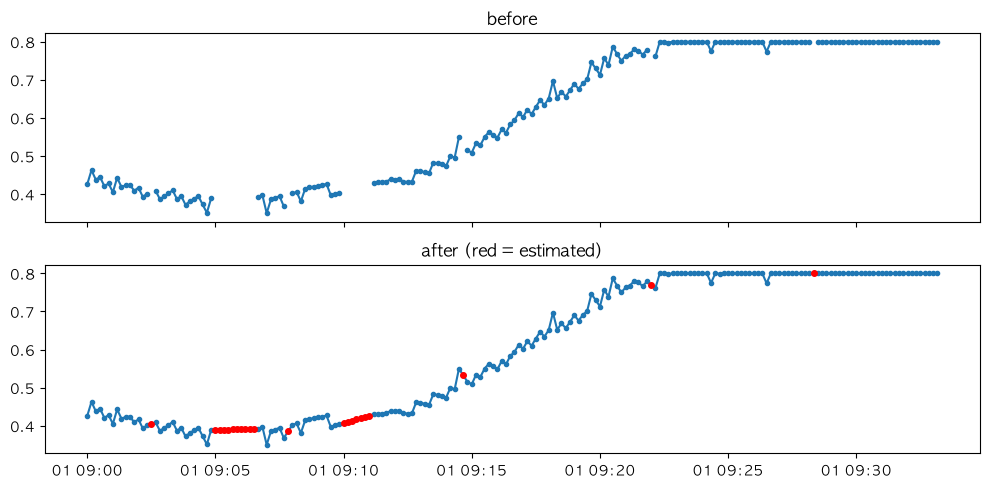

In [7]:
# [다중 센서 일괄 보간 및 차트상 보간 데이터(Estimated) 하이라이트 시각화]
# 1. norm.interpolate(method='time'): 데이터프레임 내 모든 센서 컬럼의 누락값을 시간 보간법으로 일시에 수복합니다.
# 2. was_na: 보간 전에 결측 상태였던 행들을 불리언 시리즈 형태로 기억합니다.
# 3. ax[1].plot(..., 'ro'): 보간 후 복원된 시리즈 위에 원래 NaN이었던 포인트만 빨간 동그라미(Red Circle) 마커로 포개어 그립니다.
# * 작업자에게 보간을 통해 보정 완료된 기계 온도 그래프를 보여줄 때,
#   "어떤 값이 실제 측정치이고 어떤 값이 시스템이 추정한 보간치인가"를 명확하게 구분해 시각 보고서로 제출합니다.
# * markersize 값을 적절히 조율하여 원본 플롯 라인 뒤의 점들이 시인성 높게 표출되도록 제어해야 합니다.

print('복원 전:', norm.isna().sum().to_dict())        # 22, 22
restored = norm.interpolate(method='time')

print('복원 후:', restored.isna().sum().to_dict())     # 0, 0
was_na = norm['제어출력'].isna()

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(norm.index, norm['제어출력'], marker='.'); ax[0].set_title('before')
ax[1].plot(restored.index, restored['제어출력'], marker='.')

ax[1].plot(restored.index[was_na], restored['제어출력'][was_na], 'ro', markersize=4)
ax[1].set_title('after (red = estimated)'); plt.tight_layout()

plt.show()

## 실습 5. 전처리 파이프라인 함수
불러오기·정규화·시간 보간을 한 함수로 묶어 자동화

목표
- 불러오기·정규화·시간 보간을 한 함수로 묶어 전처리를 자동화

단계
- 파일을 시간 인덱스로 만들고 격자로 정규화하는 함수 작성
- 함수 안에서 시간 보간으로 결측을 채우기
- 처리 전후 결측을 함께 출력해 검증

예상 결과
- 처리 전 각 22칸, 처리 후 0; 한 번의 호출로 깨끗한 데이터

In [8]:
# [재사용성을 확보한 모듈화된 전처리 파이프라인 함수 설계]
# 1. def preprocess(path, freq='10s'): CSV 파일 경로와 타겟 주기를 매개변수(Parameter)로 받아 분석 전 과정을 추상화합니다.
# 2. 데이터 수신 -> datetime 타입 변환 -> 시간 인덱싱 및 정렬 -> asfreq 격자 정규화 -> 시간 보간 완료 후 깨끗한 데이터프레임 반환.
# * 공장에서 센서 CSV 파일이 매일 아침 새로 수집되는 상황에서, 매번 타이핑하지 않고
#   정형화된 전처리 함수(preprocess)에 파일 경로만 입력해 결측과 주기를 일괄 정제하여 활용합니다.
# * 함수 내에서 계산 결과를 외부로 내보내기 위해 `return` 구문을 빠트리지 않는 것이 매우 중요합니다.

def preprocess(path, freq='10s'):
    d = pd.read_csv(path)
    d['timestamp'] = pd.to_datetime(d['timestamp'])
    d = d.set_index('timestamp').sort_index()
    g = d[['제어출력', '소입로온도']].asfreq(freq)

    print('전:', g.isna().sum().to_dict())            # 22, 22
    clean = g.interpolate(method='time')
    print('후:', clean.isna().sum().to_dict())         # 0, 0

    return clean

clean = preprocess('22_열처리.csv')

전: {'제어출력': 22, '소입로온도': 22}
후: {'제어출력': 0, '소입로온도': 0}


## 실습 6. 주기별 복합 데이터 정제
여러 정규화 주기로 정제해 행·결측·보간 결과 비교

목표
- 여러 정규화 주기로 정제해 행 수·결측·보간 결과를 비교

단계
- 10초·30초·1분 주기로 각각 격자 정규화
- 각 주기의 행 수와 정규화 직후 결측을 세기
- 시간 보간 후 결측이 모두 사라지는지 확인

예상 결과
- 주기가 길수록 행·결측이 줄고, 보간 후 모두 0

In [9]:
# [정규화 타겟 주기(10초, 30초, 1분)별 누락 패턴과 보간 동작 자동 대조]
# 1. '10s', '30s', '1min' 등 다운샘플링의 강도가 다른 주기를 순회하며 각각 `asfreq` 격자 크기 변화를 봅니다.
# 2. 주기가 길어질수록(1분) 총 행의 수와 그로 인해 채워야 할 NaN(결측)의 분량이 변화하며 보간 후 결과는 모두 0으로 완수됩니다.
# * 분석가에게 고해상도(10s) 가공을 쓸지, 장기 상태 판독을 위해 가벼운 저해상도(1min) 가공을 채택할지
#   주기별 보간 통계치를 비교해 적정 분석 주기를 조절할 수 있는 유연성을 제공합니다.
# * 루프 내부에서 `freq` 인자를 문자열 형태로 `asfreq()`에 적확하게 전달해야 격자가 맞게 구성됩니다.

for freq in ['10s', '30s', '1min']:
    n = df[['제어출력']].asfreq(freq)
    c = n['제어출력'].interpolate(method='time')
    print(freq, '행', len(n), '결측', int(n['제어출력'].isna().sum()), '보간후', int(c.isna().sum()))

10s 행 200 결측 22 보간후 0
30s 행 67 결측 9 보간후 0
1min 행 34 결측 5 보간후 0


## 실습 7. 정비 판단 연결 리포트
복원 데이터의 추세로 설비 상태를 분류해 리포트 작성

목표
- 복원한 데이터의 추세로 설비 상태를 분류해 정비 판단 리포트를 작성

단계
- 복원한 제어출력을 이동평균으로 추세와 변화량 계산
- 변화량 기준으로 정상·주의·정비 검토 상태를 분류
- 추세·변화량·판단·추정 비율을 리포트로 출력

예상 결과
- 최종 추세 0.8·변화 0.374 → 정비 검토 필요, 추정 비율 11퍼센트

In [10]:
# [정제 완료된 시계열 데이터 기반 룰 베이스 설비 보전 자동 의사결정 판정]
# 1. `clean_v.rolling(window=6)`: 보간이 잘 끝난 깨끗한 제어출력 변수를 활용해 60초(6*10s) 이동평균선(trend)을 뽑습니다.
# 2. `change = trend.iloc[-1] - trend.iloc[0]`: 전체 작동 전 구간에 걸친 추세 수치의 총 변화량을 구합니다.
# 3. 다중 if-else 조건문: 최종 요약 수치(`final > 0.55`)와 변화량 조건에 따라 '정비 검토 필요', '주의', '정상' 상태를 자동 판정합니다.
# * 누락 시점 보간 전처리부터 최종 분석과 통계치 검증, 기계적 열화 해석에 이르는 파이프라인의 완성형으로
#   스마트 팩토리에서 실시간 원격 상태 판정 스크립트를 주기적으로 백그라운드 구동하는 실무 모형을 제시합니다.
# * `min_periods=1`을 지정해 주어야 앞단의 결측(NaN) 구간에서도 정상적인 연산을 수행해 NaN 반환을 최소화합니다.

clean_v = norm['제어출력'].interpolate(method='time')
trend = clean_v.rolling(window=6, min_periods=1).mean()
final = trend.iloc[-1]; change = trend.iloc[-1] - trend.iloc[0]
status = '정비 검토 필요' if (final > 0.55 or change > 0.1) else ('주의' if change > 0.05 else '정상')

print('최종 추세:', round(final, 3), '변화량:', round(change, 3))   # 0.8 / 0.374
print('판단:', status)                                            # 정비 검토 필요
print('추정값 비율(%):', round(norm['제어출력'].isna().mean()*100, 1))  # 11.0

최종 추세: 0.8 변화량: 0.374
판단: 정비 검토 필요
추정값 비율(%): 11.0
